## Bài toán : 

cho dữ liệu giá nhà phụ thuộc vào 1 yếu tố là diện tích được lưu trong file data_linear.csv  
yêu cầu :  
1. xây dựng model linear regression
2. prediction: dự đoán xem giá của ngôi nahf 50 $m^2$ có giá bao nhiêu dựa vào mô hình đã tìm được ở trên 
 

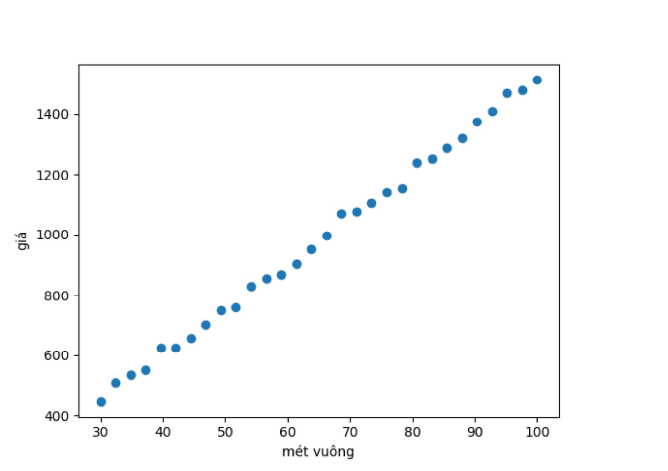

bài toán bây giờ là ta sẽ tìm 1 đường thẳng linear đi qua các điểm này sao cho tốt nhất vì bài toán có 1 tham số là diện tích nên đường thẳng đó có dạng  

$y = w_1*x + w_0$ => để tìm được đường thẳng này ta dựa vào các dữ liệu training để tìm các tham số $w_0 và w_1$  

=> xây dựng hàm loss Function 

$L(w) = \frac{1}{2N} \sum_{i=1}^{N} (y_i - x^T_i w)^2$  
sử dụng thuật toán gradient descent để giải tìm giá trị nhỏ nhất của hàm loss function này  
hoặc có thể sủ dụng công thức chính xác nghiệm của linear_regression 

Sử dụng thuật toán gradient  
khai báo giá trị w = $w_0$ chọn ngẫu nhiên giá trị 
sau đó cập nhập w theo công thức  
$w = w - learning_rate*\Delta L(w)$   
nó sẽ được khai triển thành 
$ w=w+η(y_i​−w^Tx_i​)x_i $  
error = $y_i - \hat y$  
=> $ w = w + η*error* x_i$

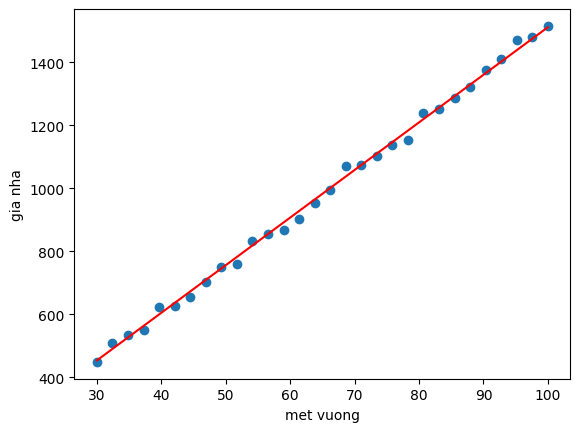

gia nha cho 50 M^2  [755.68795083]


In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

data = pd.read_csv('data_linear.csv').values  
N = data.shape[0]
x = data[:,0].reshape(-1,1) 
y = data[:,1].reshape(-1,1) 

x = np.hstack((np.ones((N,1)),x))

w  = np.array([0.,1.]).reshape(-1,1)

# training model
numOfiteration = 100  # điều kiện dừng vì sử dụng 100 lần lặp do tập dữ liệu ở đây là nhỏ thường sẽ sủ dụng điều kiện dừng cảu gradients descent epsilon = 1e-6
cost = np.zeros((numOfiteration))
learning_rate = 0.000001 
for i in range(1, numOfiteration) : 
    r = np.dot(x,w) - y
    cost[i] = 0.5*np.sum(r*r)
    w[0] -= learning_rate*np.sum(r)
    w[1] -= learning_rate*np.sum(np.multiply(r,x[:,1].reshape(-1,1)))

predict = np.dot(x,w) 

plt.scatter(x[:,1], y)
plt.plot(x[:,1], w[0] + w[1]*x[:,1], 'r')

plt.xlabel("met vuong")
plt.ylabel("gia nha")

plt.show()

x1 = 50 
y1 = w[0] + w[1]*x1 
print("gia nha cho 50 M^2 ", y1)
